# Length-of-Stay & Cost-of-Care: Exploratory Data Analysis

**Data source:** Synthetic patient records generated with [Synthea](https://github.com/synthetichealth/synthea) (500 simulated patients, Massachusetts population). Fully synthetic — no PHI, no HIPAA scope.

**Input:** `model_features.csv`, built by the SQL feature-engineering pipeline (`sql/02_feature_engineering.sql`). One row = one emergency/inpatient/urgentcare encounter.

**Goal of this notebook:** understand the shape of the target variables (LOS, cost), check data quality, and identify which features carry real signal before modeling.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

df = pd.read_csv("model_features.csv", parse_dates=["start_ts"])
print(df.shape)
df.head()


(4415, 24)


,encounter_id,patient_id,los_days,total_claim_cost,is_extended_stay,encounterclass,start_ts,admit_day_of_week,admit_on_weekend,admit_hour,...,ethnicity,age_at_admission,payer_type,comorbidity_count,new_conditions_count,procedure_count,meds_last_90_days,prior_admission_count,days_since_last_discharge,is_30day_readmission
0,e8a04254-1004-e1e9-71f6-da91afdd66d8,e8a04254-1004-e1e9-ed60-40ac7b6b2f47,0.042,1008.98,0,emergency,2026-08-22 20:43:15,6,1,20,...,nonhispanic,13,PRIVATE,3,2,2,0,1,2596.9,0
1,77576681-70f3-74d3-9d63-94e0bfed3125,77576681-70f3-74d3-e60e-bb7c3a782eb8,0.030,573.98,0,urgentcare,2026-05-20 22:05:33,3,0,22,...,nonhispanic,46,PRIVATE,18,5,3,1,10,248.3,0
2,cea9384c-b73d-bcff-495c-68f891aa1b86,cea9384c-b73d-bcff-8454-7a71a56aa47b,0.036,797.72,0,urgentcare,2026-07-23 13:53:14,4,0,13,...,nonhispanic,63,PRIVATE,22,3,6,3,2,28.0,1
3,d618f3ee-2948-b184-5f4d-b91d35d9de08,d618f3ee-2948-b184-1e22-58f8b059aabc,1.000,34375.66,0,inpatient,2026-05-14 13:58:20,4,0,13,...,nonhispanic,62,PRIVATE,15,1,21,8,2,3590.9,0
4,e94d81a5-d112-4634-e560-aecacf3e527a,e94d81a5-d112-4634-f045-637a4b74075f,0.042,36342.12,0,emergency,1984-08-12 13:00:20,0,1,13,...,nonhispanic,41,PRIVATE,10,1,2,0,3,1849.5,0


## 1. Data Quality Check

Before trusting any distribution, confirm there's no missingness or structural issue hiding in the feature table.

In [2]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values:")
print(missing if len(missing) else "None")

print("\nRow count by encounter class:")
print(df["encounterclass"].value_counts())

print("\nDuplicate encounter_id check:", df["encounter_id"].duplicated().sum())


Columns with missing values:
days_since_last_discharge    492
dtype: int64

Row count by encounter class:
encounterclass
urgentcare    2097
emergency     1701
inpatient      617
Name: count, dtype: int64

Duplicate encounter_id check: 0


**Note on `days_since_last_discharge`:** missing values here are *expected* — they mean this was the patient's first admission in the dataset, not a data quality issue. We'll leave it as NaN rather than fill it with 0, since 0 would falsely imply "readmitted same day."

## 2. Target Variable: Length of Stay

LOS is the primary regression target. Healthcare LOS is almost always right-skewed — most stays are short, with a long tail of complex cases.

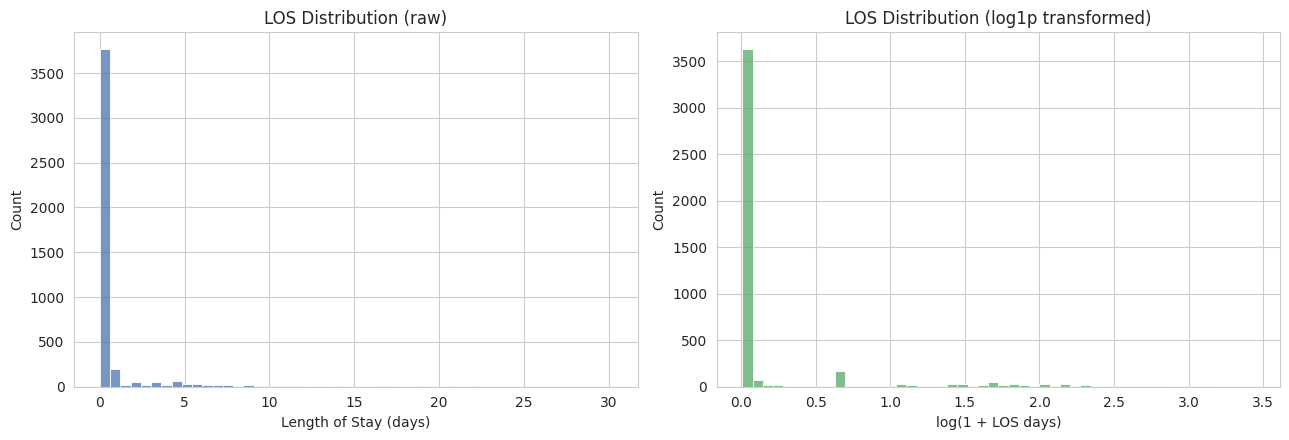

count    4415.000000
mean        0.728073
std         2.422729
min         0.010000
25%         0.027000
50%         0.042000
75%         0.042000
max        30.198000
Name: los_days, dtype: float64

Skewness (raw): 5.31
Skewness (log1p): 2.83

95th percentile LOS: 5.07 days
99th percentile LOS: 12.88 days


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(df["los_days"], bins=50, ax=axes[0], color="#4C72B0")
axes[0].set_title("LOS Distribution (raw)")
axes[0].set_xlabel("Length of Stay (days)")

sns.histplot(np.log1p(df["los_days"]), bins=50, ax=axes[1], color="#55A868")
axes[1].set_title("LOS Distribution (log1p transformed)")
axes[1].set_xlabel("log(1 + LOS days)")

plt.tight_layout()
plt.show()

print(df["los_days"].describe())
print(f"\nSkewness (raw): {df['los_days'].skew():.2f}")
print(f"Skewness (log1p): {np.log1p(df['los_days']).skew():.2f}")
print(f"\n95th percentile LOS: {df['los_days'].quantile(0.95):.2f} days")
print(f"99th percentile LOS: {df['los_days'].quantile(0.99):.2f} days")


**Takeaway:** raw LOS is heavily right-skewed (long tail of complex/inpatient stays). A log1p transform substantially reduces skew, which is why we'll train the regression model on `log1p(los_days)` rather than raw days, then exponentiate predictions back for reporting.

For the classification framing, `is_extended_stay` (LOS > 7 days) captures this tail directly.

## 3. Target Variable: Cost

Same skew check for `total_claim_cost`, since cost and LOS are related but not identical — a short stay with heavy procedures can still be expensive.

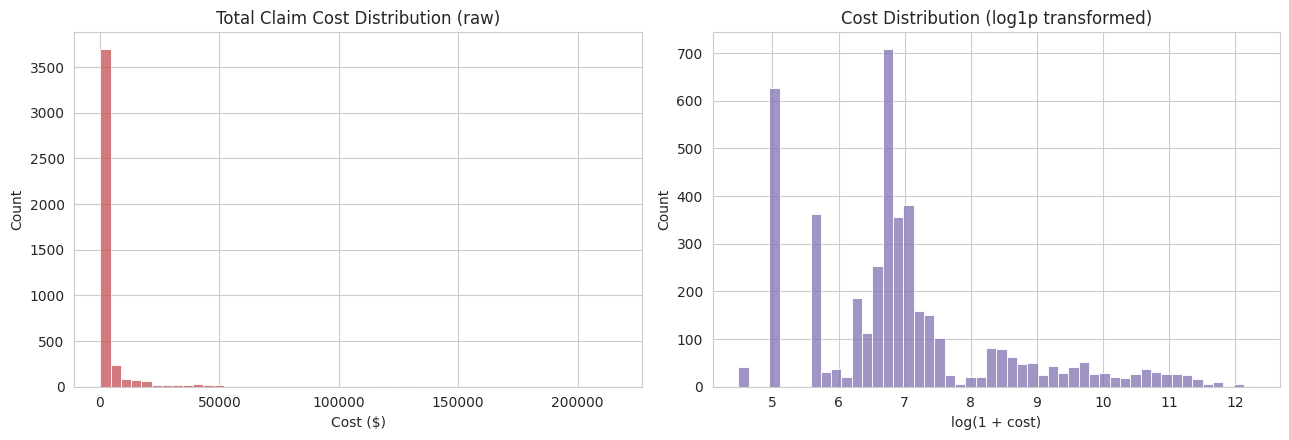

count      4415.000000
mean       5266.803520
std       16020.304033
min          87.710000
25%         426.970000
50%         872.300000
75%        1520.180000
max      216090.810000
Name: total_claim_cost, dtype: float64

Correlation between LOS and cost: 0.670


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(df["total_claim_cost"], bins=50, ax=axes[0], color="#C44E52")
axes[0].set_title("Total Claim Cost Distribution (raw)")
axes[0].set_xlabel("Cost ($)")

sns.histplot(np.log1p(df["total_claim_cost"]), bins=50, ax=axes[1], color="#8172B2")
axes[1].set_title("Cost Distribution (log1p transformed)")
axes[1].set_xlabel("log(1 + cost)")

plt.tight_layout()
plt.show()

print(df["total_claim_cost"].describe())
print(f"\nCorrelation between LOS and cost: {df['los_days'].corr(df['total_claim_cost']):.3f}")


## 4. Cost Concentration

The classic healthcare-analytics finding: a small share of patients/encounters drives a disproportionate share of total cost. This is the basis for a 'target the top decile for care management' recommendation in the case study.

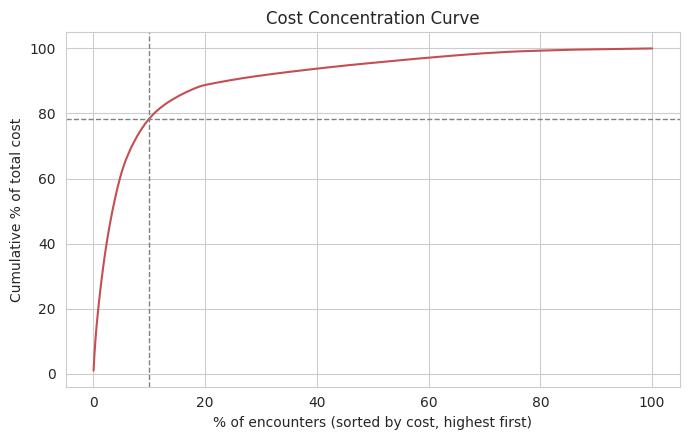

Top 10% of encounters by cost account for 78.4% of total claim cost.


In [5]:
cost_sorted = df["total_claim_cost"].sort_values(ascending=False).reset_index(drop=True)
cum_pct = cost_sorted.cumsum() / cost_sorted.sum()

top_10pct_n = int(len(cost_sorted) * 0.10)
top_10pct_cost_share = cum_pct.iloc[top_10pct_n - 1]

plt.figure(figsize=(7, 4.5))
plt.plot(np.arange(1, len(cum_pct) + 1) / len(cum_pct) * 100, cum_pct * 100, color="#C44E52")
plt.axvline(10, color="gray", linestyle="--", linewidth=1)
plt.axhline(top_10pct_cost_share * 100, color="gray", linestyle="--", linewidth=1)
plt.xlabel("% of encounters (sorted by cost, highest first)")
plt.ylabel("Cumulative % of total cost")
plt.title("Cost Concentration Curve")
plt.tight_layout()
plt.show()

print(f"Top 10% of encounters by cost account for {top_10pct_cost_share*100:.1f}% of total claim cost.")


## 5. LOS by Encounter Class

Inpatient, emergency, and urgent care are fundamentally different populations — worth checking they behave differently before pooling them into one model.

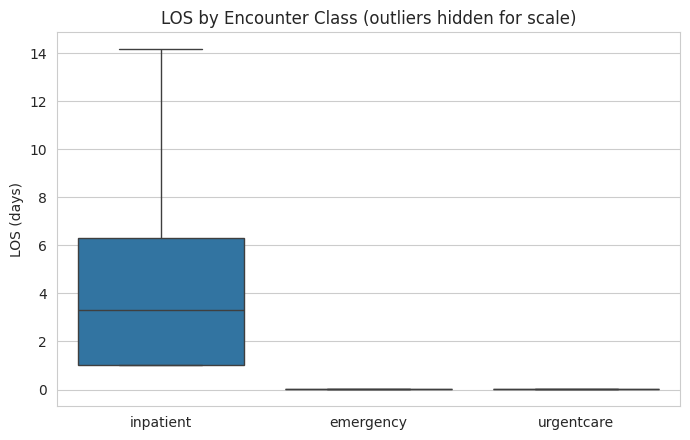

los_days              total_claim_cost                
                   mean median count             mean    median count
encounterclass                                                       
emergency          0.16   0.04  1701          2627.14    815.70  1701
inpatient          4.68   3.32   617         27395.64  13537.81   617
urgentcare         0.02   0.03  2097           897.03    860.17  2097

In [6]:
order = df.groupby("encounterclass")["los_days"].median().sort_values(ascending=False).index

plt.figure(figsize=(7, 4.5))
sns.boxplot(data=df, x="encounterclass", y="los_days", order=order, showfliers=False)
plt.title("LOS by Encounter Class (outliers hidden for scale)")
plt.ylabel("LOS (days)")
plt.xlabel("")
plt.tight_layout()
plt.show()

df.groupby("encounterclass")[["los_days", "total_claim_cost"]].agg(["mean", "median", "count"]).round(2)


**Takeaway:** inpatient encounters drive essentially all of the multi-day LOS tail — emergency and urgent care are near-zero LOS by definition. Depending on your modeling goal, consider building the LOS regression on inpatient encounters only, and treating ED/urgent-care as a separate 'will this visit escalate to admission' classification problem.

## 6. Comorbidity Burden vs. LOS

One of the strongest expected predictors: patients carrying more active conditions into an admission should, on average, stay longer.

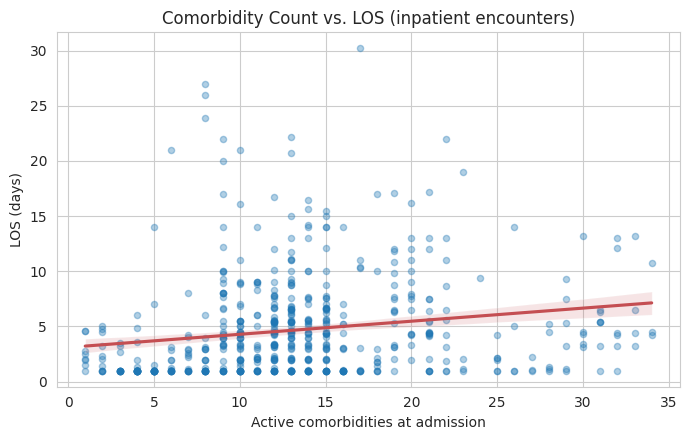

Correlation (inpatient only): 0.180


In [7]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.regplot(
    data=df[df["encounterclass"] == "inpatient"],
    x="comorbidity_count", y="los_days",
    scatter_kws={"alpha": 0.35, "s": 20}, line_kws={"color": "#C44E52"}, ax=ax
)
ax.set_title("Comorbidity Count vs. LOS (inpatient encounters)")
ax.set_xlabel("Active comorbidities at admission")
ax.set_ylabel("LOS (days)")
plt.tight_layout()
plt.show()

corr = df.loc[df["encounterclass"]=="inpatient", ["comorbidity_count","los_days"]].corr().iloc[0,1]
print(f"Correlation (inpatient only): {corr:.3f}")


## 7. Prior Utilization & Readmission Signal

Does admission history predict this stay's LOS or the likelihood of a 30-day readmission?

/tmp/ipykernel_213/3946777471.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["Not a readmission", "30-day readmission"])


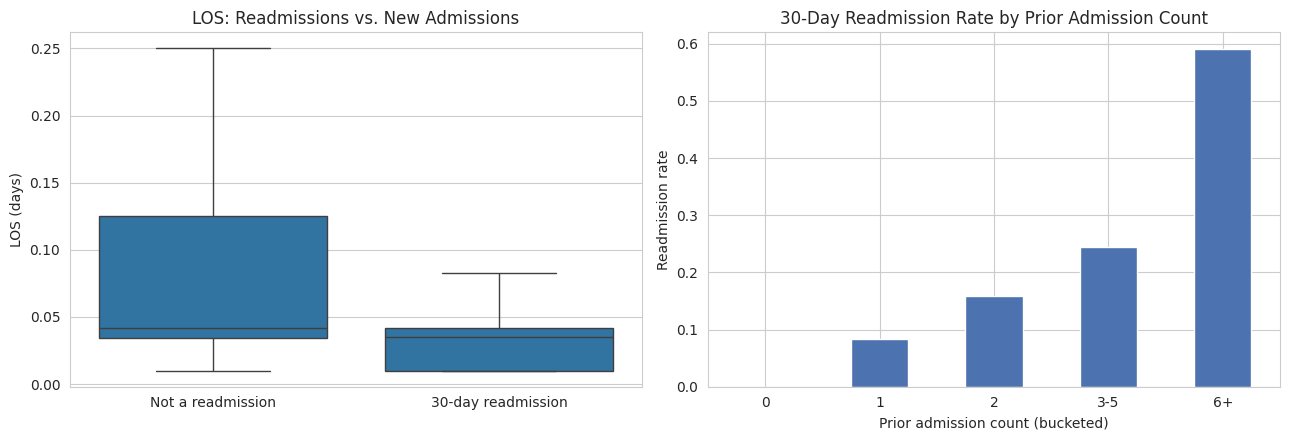

Overall 30-day readmission rate: 49.0%


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.boxplot(
    data=df, x="is_30day_readmission", y="los_days", ax=axes[0], showfliers=False
)
axes[0].set_xticklabels(["Not a readmission", "30-day readmission"])
axes[0].set_title("LOS: Readmissions vs. New Admissions")
axes[0].set_ylabel("LOS (days)")
axes[0].set_xlabel("")

readmit_by_prior = df.groupby(pd.cut(df["prior_admission_count"], bins=[-1,0,1,2,5,100],
                                       labels=["0","1","2","3-5","6+"]))["is_30day_readmission"].mean()
readmit_by_prior.plot(kind="bar", ax=axes[1], color="#4C72B0")
axes[1].set_title("30-Day Readmission Rate by Prior Admission Count")
axes[1].set_ylabel("Readmission rate")
axes[1].set_xlabel("Prior admission count (bucketed)")
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print(f"Overall 30-day readmission rate: {df['is_30day_readmission'].mean()*100:.1f}%")


**Takeaway:** patients with more prior admissions show a higher 30-day readmission rate — this supports including `prior_admission_count` and `days_since_last_discharge` as model features, and supports a care-management recommendation targeting patients with 2+ prior admissions.

## 8. Payer Type: Cost & LOS Differences

Relevant for the cost-modeling angle of this project — does payer type correlate with cost/LOS independent of clinical severity?

In [9]:
summary = df.groupby("payer_type").agg(
    n=("encounter_id","count"),
    avg_los=("los_days","mean"),
    avg_cost=("total_claim_cost","mean"),
    avg_comorbidity=("comorbidity_count","mean"),
    pct_extended_stay=("is_extended_stay","mean"),
).round(2).sort_values("avg_cost", ascending=False)
summary["pct_extended_stay"] = (summary["pct_extended_stay"]*100).round(1)
summary


,n,avg_los,avg_cost,avg_comorbidity,pct_extended_stay
payer_type,,,,,
GOVERNMENT,2704,0.85,6629.41,20.42,3.0
PRIVATE,1019,0.65,3354.62,11.36,3.0
NO_INSURANCE,692,0.37,2758.17,22.53,2.0


## 9. Correlation Overview (Numeric Features)

A quick correlation heatmap to catch multicollinearity before modeling (e.g. `comorbidity_count` and `meds_last_90_days` are likely related).

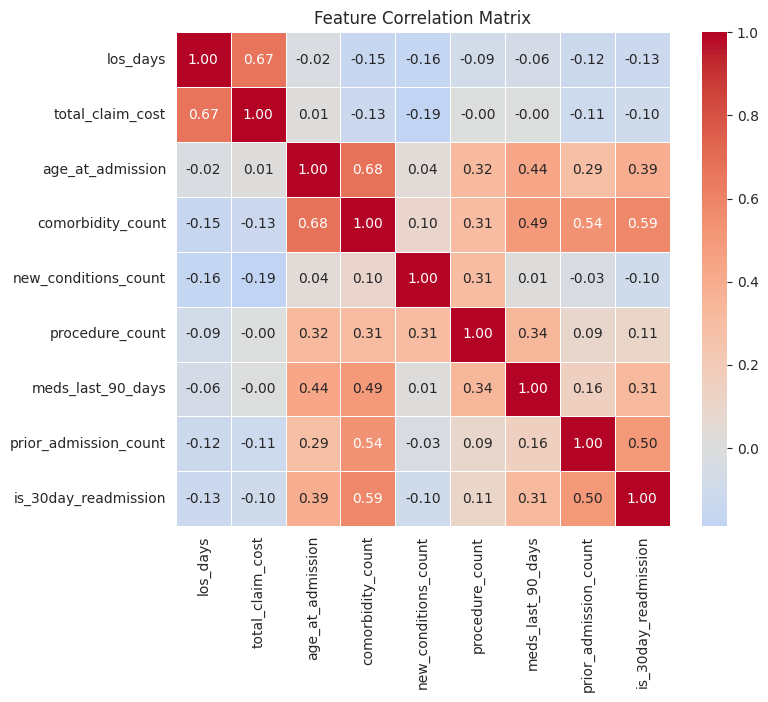

In [10]:
numeric_cols = [
    "los_days","total_claim_cost","age_at_admission","comorbidity_count",
    "new_conditions_count","procedure_count","meds_last_90_days",
    "prior_admission_count","is_30day_readmission"
]
corr = df[numeric_cols].corr()

plt.figure(figsize=(8.5, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, linewidths=0.5)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()


## 10. Summary of EDA Findings

1. **LOS and cost are both right-skewed** — model on `log1p()` transforms, report back-transformed metrics (days, dollars) for stakeholders.
2. **Encounter class matters a lot** — inpatient stays behave completely differently from ED/urgent care. Consider modeling inpatient LOS separately, or including `encounterclass` as a strong categorical feature at minimum.
3. **Comorbidity count correlates with LOS** for inpatient encounters — supports clinical intuition and is a genuinely useful engineered feature (not just a proxy for age).
4. **Cost is concentrated** — a small share of encounters accounts for a disproportionate share of total spend, supporting a targeted care-management recommendation.
5. **Prior admission history predicts readmission risk** — `prior_admission_count` and `days_since_last_discharge` should go into the model, and this relationship alone supports an actionable recommendation (flag patients with 2+ priors for discharge planning follow-up).
6. **Class imbalance** — extended stays (>7 days) are a minority class (~3% here). The classification model will need class weighting or resampling, and precision/recall will matter more than accuracy.

**Next step:** feature encoding + train/test split + baseline models (linear/logistic regression) before moving to XGBoost/Random Forest.
